In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.min_features import min_features

warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)

# pos = pd.read_csv('data/raw/player_positions/player_positions.csv')
s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s25['STARTING'] = s25['START_POSITION'].notna().astype(int)
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26['STARTING'] = s26['START_POSITION'].notna().astype(int)
s26.tail()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
209,2025-26,201145,Jeff Green,Jeff,1610612745,HOU,Houston Rockets,22501194,2026-04-12T00:00:00,HOU vs. MEM,W,24.183333,2,8,0.250,0,4,0.00,2,2,1.000,2,3,5,1,3,1,1,0,2,1,6,7,16.5,0,0,16.0,1,24:11,1,103.9,105.5,105.5,86.1,91.1,91.1,17.8,14.4,14.4,0.059,0.33,7.7,0.063,0.100,0.081,23.1,23.3,0.250,0.338,0.174,0.181,114.13,110.16,91.80,110.16,0.016,55,2.0,8.0,48,105,0.457,14,49,0.286,22,30,0.733,21,43,64,23,11.0,10,8,6,10,24,132,31.0,122.0,128.2,94.9,98.1,27.1,30.1,0.479,2.09,14.9,0.452,0.821,0.627,0.107,0.524,0.558,107.3,103.0,85.83,103,0.642,1610612763,MEM,Memphis Grizzlies,39,95,0.411,13,49,0.265,10,10,1.000,6,31,37,23,13.0,8,6,8,24,10,101,-31.0,94.9,98.1,122.0,128.2,-27.1,-30.1,0.590,1.77,16.9,0.179,0.548,0.373,0.126,0.479,0.508,107.3,103.0,85.83,103,0.358,NaN,PF,39.0,0
210,2025-26,1631342,Daeqwon Plowden,Daeqwon,1610612758,SAC,Sacramento Kings,22501200,2026-04-12T00:00:00,SAC @ POR,L,22.200000,2,5,0.400,1,4,0.25,3,3,1.000,0,1,1,2,3,0,2,0,4,1,8,-8,15.2,0,0,16.0,1,22:12,1,118.2,114.6,114.6,127.2,134.0,134.0,-9.0,-19.5,-19.5,0.100,0.67,18.2,0.000,0.034,0.022,27.3,26.5,0.500,0.633,0.173,0.184,103.83,102.70,85.59,102.70,0.017,48,2.0,5.0,40,83,0.482,7,21,0.333,23,31,0.742,15,32,47,24,17.0,7,8,3,18,21,110,-12.0,111.5,112.2,120.1,123.2,-8.6,-11.0,0.600,1.41,17.3,0.370,0.600,0.495,0.173,0.524,0.569,100.1,98.5,82.08,98,0.478,1610612757,POR,Portland Trail Blazers,47,101,0.465,16,46,0.348,12,15,0.800,18,28,46,28,12.0,9,3,8,21,18,122,12.0,120.1,123.2,111.5,112.2,8.6,11.0,0.596,2.33,18.8,0.400,0.630,0.505,0.121,0.545,0.567,100.1,98.5,82.08,99,0.522,F,SG,27.0,1
211,2025-26,1630286,Trevon Scott,Trevon,1610612751,BKN,Brooklyn Nets,22501192,2026-04-12T00:00:00,BKN @ TOR,L,26.050000,3,8,0.375,2,5,0.40,0,0,0.000,1,2,3,1,2,1,0,0,2,0,8,-17,14.1,0,0,16.0,1,26:03,1,104.8,109.3,109.3,137.8,135.7,135.7,-32.9,-26.5,-26.5,0.053,0.50,9.1,0.038,0.125,0.071,18.2,18.2,0.500,0.500,0.164,0.161,102.67,101.34,84.45,101.34,0.027,54,3.0,8.0,35,86,0.407,9,34,0.265,22,29,0.759,13,25,38,21,16.0,9,0,8,27,20,101,-35.0,99.3,101.0,136.3,136.0,-37.1,-35.0,0.600,1.31,15.6,0.255,0.844,0.471,0.160,0.459,0.511,100.8,100.0,83.33,100,0.277,1610612761,TOR,Toronto Raptors,51,80,0.638,12,27,0.444,22,29,0.759,3,40,43,36,10.0,9,8,0,20,27,136,35.0,136.3,136.0,99.3,101.0,37.1,35.0,0.706,3.60,25.5,0.156,0.745,0.529,0.100,0.713,0.733,100.8,100.0,83.33,100,0.723,C,NaN,NaN,1
204,2025-26,1629020,Jarred Vande

In [5]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)

    # Derived features
    df["IS_DNP"] = (df["MIN"] == 0).astype(int)
    df["DNP_STREAK"]     = df.groupby("PLAYER_ID")["IS_DNP"].transform(
    lambda x: x.groupby((x != x.shift()).cumsum()).cumcount())
    df["GAMES_SINCE_DNP"] = df.groupby("PLAYER_ID")["IS_DNP"].transform(
    lambda x: x[::-1].cumsum()[::-1])

    df = min_features(df)

    df['TEAM_MIN_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['MIN_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L10'] = (
    df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll10']
    .rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_BY_POS_L10'] = (df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_BY_POS_L10'] = (df.groupby(['TEAM_ID', 'GAME_DATE', 'pos'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))

    df['USG_EWM_L10'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['USG_EWM_L5'] = (df.groupby('PLAYER_ID')['USG_PCT'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L10'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=12, adjust=False).mean()))
    df['MIN_EWM_L5'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=5, adjust=False).mean()))
    df['MIN_EWM_L3'] = (df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean()))
    
    df['MIN_TREND'] = (df['MIN_EWM_L3'] - df['MIN_EWM_L10'])
    df['STARTER_X_MIN_AVG'] = df['STARTING'] * df['MIN_season_avg']
    df['AGE_X_B2B'] = df['age'] * df['IS_B2B']
    df['HOME_X_MIN_AVG'] = df['IS_HOME'] * df['MIN_season_avg']
    df['EXPECTED_MARGIN'] = (df['TEAM_NET_RATING_roll5'] - df['OPP_NET_RATING_roll5']).abs()
    min_max_l10 = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).max())
    min_min_l10 = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).min())
    df['ROTATION_GAP_L10'] = min_max_l10 - min_min_l10

    # Calculate the player's personal season-to-date baseline
    player_stats = df.groupby('PLAYER_ID')['MIN']
    # Use expanding() to avoid look-ahead bias (only uses games played UP TO that date)
    df['SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    df['SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    # The Z-score of their current 10-game average relative to their own season
    df['MIN_ROLE_Z_SCORE'] = (df['MIN_roll10'] - df['SEASON_MEAN']) / df['SEASON_STD']
    df['MIN_VOLATILITY_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(
    lambda x: x.rolling(window=10, min_periods=1).std().shift(1))
    df['MIN_VOLATILITY_RELATIVE'] = df['MIN_VOLATILITY_L10'] / df['MIN_roll10']

    df['HIGH_MIN_PLAYER'] = (df['MIN_roll10'] > 30).astype(int)
    df['HIGH_MIN_TIER'] = np.nan
    mask = df['MIN_EWM_L10'].notna()
    df.loc[mask, 'HIGH_MIN_TIER'] = pd.cut(
        df.loc[mask, 'MIN_EWM_L10'],
        bins=[0, 20, 25, 30, 34, 100],
        labels=[0, 1, 2, 3, 4],
        include_lowest=True,).astype(int)
        
    df["GP"] = df.groupby("PLAYER_ID").cumcount()
    le = LabelEncoder()
    df['POSITION_ENC'] = le.fit_transform(df['pos'])
    df['PLAYER_ENC'] = le.fit_transform(df['PLAYER_NAME'])
    df['ROLE_LOCK'] = (
    df['STARTER_ROLL10_PCT'] * df['MIN_std10'].apply(lambda x: 1/x))  # high start% + low variance = locked in role = safest bet
    df['ROLE_SHOCK'] = (
    df['MIN_EWM_L5'] - df['MIN_EWM_L10']          # short vs long term gap
    ) / df['MIN_EWM_L10']                            # normalized as % change
    df['PM_PER_MIN']    = df['PLUS_MINUS_lag1'] / df['MIN_lag1'].replace(0, np.nan)
    df['PM_PER_MIN_R10']= df['PM_PER_MIN'].transform(lambda x: x.shift(1).rolling(10).mean())

    df['MIN_MIN_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).min())
    df['MIN_MAX_L10'] = df.groupby('PLAYER_ID')['MIN'].transform(lambda x: x.shift(1).rolling(10).max())


    df['MIN_AVG_X_OPP_POSS_L10'] = df['MIN_season_avg'] * df['OPP_POSS_roll10']
    df['MIN_AVG_X_OPP_DEF_RATING_L10'] = df['MIN_season_avg'] * df['OPP_DEF_RATING_roll10']
    df['ACTIVE_STARS_X_USG_PCT'] = df['ACTIVE_STARS_COUNT'] * df['USG_PCT_season_avg']
    df['MIN_AVG_X_ACTIVE_STARS_COUNT'] = df['MIN_season_avg'] * df['ACTIVE_STARS_COUNT']


    
    df = df[df['MIN'] > 0]
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.shape)
df[df['PLAYER_NAME'] == 'LeBron James']
# df.to_csv('data/processed/training/S26_TRAINING_MIN.csv', index=False)

(105272, 317)


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,IS_DNP,DNP_STREAK,GAMES_SINCE_DNP,MIN_roll3,PTS_roll3,REB_roll3,AST_PCT_roll3,OREB_PCT_roll3,DREB_PCT_roll3,TM_TOV_PCT_roll3,PLUS_MINUS_roll3,PF_roll3,POSS_roll3,PIE_roll3,USG_PCT_roll3,TS_PCT_roll3,NET_RATING_roll3,OFF_RATING_roll3,DEF_RATING_roll3,MIN_roll5,PTS_roll5,REB_roll5,AST_PCT_roll5,OREB_PCT_roll5,DREB_PCT_roll5,TM_TOV_PCT_roll5,PLUS_MINUS_roll5,PF_roll5,POSS_roll5,PIE_roll5,USG_PCT_roll5,TS_PCT_roll5,NET_RATING_roll5,OFF_RATING_roll5,DEF_RATING_roll5,MIN_roll10,PTS_roll10,REB_roll10,AST_PCT_roll10,OREB_PCT_roll10,DREB_PCT_roll10,TM_TOV_PCT_roll10,PLUS_MINUS_roll10,PF_roll10,POSS_roll10,PIE_roll10,USG_PCT_roll10,TS_PCT_roll10,NET_RATING_roll10,OFF_RATING_roll10,DEF_RATING_roll10,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,IS_DNP_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,IS_DNP_lag2,MIN_lag3,PTS_lag3,PLUS_MINUS_lag3,PIE_lag3,STARTING_lag3,POSS_lag3,USG_PCT_lag3,IS_DNP_lag3,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,REB_season_avg,AST_season_avg,STL_season_avg,BLK_season_avg,TOV_season_avg,FGM_season_avg,FGA_season_avg,FG_PCT_season_avg,FG3M_season_avg,FG3A_season_avg,FG3_PCT_season_avg,OREB_season_avg,DREB_season_avg,PLUS_MINUS_season_avg,PF_season_avg,POSS_season_avg,PIE_season_avg,USG_PCT_season_avg,TS_PCT_season_avg,NET_RATING_season_avg,TEAM_PACE_roll10,TEAM_PTS_roll5,TEAM_NET_RATING_roll5,MIN_share_proxy,PTS_share_proxy,TEAM_POSS_roll5,TEAM_POSS_share,DAYS_REST,IS_B2B,IS_HOME,GAME_NUMBER,MIN_std10,MIN_std5,MIN_std20,OPP_DEF_RATING_roll5,OPP_DEF_RATING_roll10,OPP_PACE_roll5,OPP_PACE_roll10,OPP_POSS_roll5,OPP_POSS_roll10,OPP_NET_RATING_roll5,OPP_NET_RATING_roll10,EXPECTED_PACE,PACE_DIFFERENTIAL,IS_TOP_STAR,ACTIVE_STARS_COUNT,TEAM_MIN_RANK_BY_POS_L10,TEAM_USG_RANK_BY_POS_L10,TEAM_MIN_RANK_L10,TEAM_USG_RANK_L10,USG_EWM_L10,USG_EWM_L5,MIN_EWM_L10,MIN_EWM_L5,MIN_EWM_L3,MIN_TREND,STARTER_X_MIN_AVG,AGE_X_B2B,HOME_X_MIN_AVG,EXPECTED_MARGIN,ROTATION_GAP_L10,SEASON_MEAN,SEASON_STD,MIN_ROLE_Z_SCORE,MIN_VOLATILITY_L10,MIN_VOLATILITY_RELATIVE,HIGH_MIN_PLAYER,HIGH_MIN_TIER,GP,POSITION_ENC,PLAYER_ENC,ROLE_LOCK,ROLE_SHOCK,PM_PER_MIN,PM_PER_MIN_R10,MIN_MIN_L10,MIN_MAX_L10,MIN_AVG_X_OPP_POSS_L10,MIN_AVG_X_OPP_DEF_RATING_L10,ACTIVE_STARS_X_USG_PCT,MIN_AVG_X_ACTIVE_STARS_COUNT,START_POSITION
0,2022-23,2544,LeBron James,LeBron,1610612747,LAL,Los Angeles Lakers,22200002,2022-10-18,LA

In [62]:
# cols = df.columns.tolist()
# i = cols.index("pos")  # KeyError if missing
# subset = df[cols[i + 1 :]]
# subset = subset.drop(columns=['START_POSITION'])
# MIN_FEATURES = subset.columns.tolist()
# MIN_FEATURES

In [ ]:
MIN_FEATURES = [
    'GP',                      
    'POSITION_ENC',  
    'STARTER_X_MIN_AVG',     # interaction term
    'STARTING_lag1',         # did role just change?
    'STARTER_ROLL10_PCT',    # role stability

    'TEAM_MIN_RANK_L10',     # team context
    'MIN_EWM_L10',           # smoothed load baseline
    'MIN_EWM_L3',            # short-term trend
    'MIN_lag1',              # last game specifically
    'ROLE_LOCK',             
    'ACTIVE_STARS_COUNT',    
    'TEAM_USG_RANK_L10',    
    'MIN_ROLE_Z_SCORE',                         
    'POSS_season_avg',       # one possession feature
    'MIN_MAX_L10',           # ceiling anchor for q_0.90
    'MIN_MIN_L10',           # floor anchor for q_0.10
    'SEASON_STD',            # volatility        
    
]

In [25]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = df[MIN_FEATURES + ["MIN", "GAME_DATE"]].dropna().sort_values("GAME_DATE").reset_index(drop=True)

# ── 2. Walk-forward folds ─────────────────────────────────────────────────────
N_FOLDS   = 4
min_train = int(len(ppm_df) * 0.50)
fold_size = (len(ppm_df) - min_train) // N_FOLDS

fold_results = []

for fold in range(N_FOLDS):
    train_end = min_train + fold * fold_size
    val_end   = train_end + fold_size

    train_idx = ppm_df.index[:train_end]
    val_idx   = ppm_df.index[train_end:val_end]

    X_train_f = ppm_df.loc[train_idx, MIN_FEATURES]
    X_val_f   = ppm_df.loc[val_idx,   MIN_FEATURES]
    y_train_f = ppm_df.loc[train_idx, "MIN"]
    y_val_f   = ppm_df.loc[val_idx,   "MIN"]

    # ── 3. Quantile models ────────────────────────────────────────────────────
    quantiles       = [0.10, 0.50, 0.90]
    quantile_models = {}
    quantile_preds  = {}
#Best params: {'max_depth': 6, 'learning_rate': 0.012114761889717784, 'n_estimators': 1378, 'subsample': 0.658891356913107, 
# 'colsample_bytree': 0.6610449450867388, 
# 'reg_alpha': 0.35062788508631587, 'reg_lambda': 0.7792871271834488, 'min_child_weight': 4}
    for q in quantiles:
        xgb_q = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=q,
            n_estimators=1378,
            max_depth=6,
            learning_rate=0.012114761889717784,
            subsample=0.658891356913107,
            colsample_bytree=0.6610449450867388,
            reg_alpha=0.35062788508631587,
            reg_lambda=0.7792871271834488,
            min_child_weight=4,
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50,
        )
        xgb_q.fit(
            X_train_f, y_train_f,
            eval_set=[(X_val_f, y_val_f)],
            verbose=False,
        )
        quantile_models[f"q_{q:.2f}"] = xgb_q
        quantile_preds[f"q_{q:.2f}"]  = xgb_q.predict(X_val_f)

    # ── 4. Fold diagnostics ───────────────────────────────────────────────────
    actual   = y_val_f.values
    lower    = quantile_preds["q_0.10"]
    median   = quantile_preds["q_0.50"]
    upper    = quantile_preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))

    fold_metrics = {
        "fold":           fold + 1,
        "train_rows":     len(train_idx),
        "val_rows":       len(val_idx),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {f"q_{q:.2f}": quantile_models[f"q_{q:.2f}"].best_iteration
                           for q in quantiles},
    }
    fold_results.append(fold_metrics)

    print(f"Fold {fold+1} | MAE: {fold_metrics['mae']:.3f} | "
          f"R²: {fold_metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%} | "
          f"Best iters: {fold_metrics['best_iters']}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
maes      = [f["mae"]            for f in fold_results]
r2s       = [f["r2"]             for f in fold_results]
coverages = [f["coverage_80pct"] for f in fold_results]

print(f"\n{'─'*55}")
print(f"Walk-Forward Summary ({N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f} ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(coverages):.1%} ± {np.std(coverages):.1%}  (target ~80%)")

Fold 1 | MAE: 4.319 | R²: 0.703 | 80% Coverage: 80.1% | Best iters: {'q_0.10': 568, 'q_0.50': 555, 'q_0.90': 593}
Fold 2 | MAE: 4.535 | R²: 0.676 | 80% Coverage: 78.9% | Best iters: {'q_0.10': 734, 'q_0.50': 734, 'q_0.90': 685}
Fold 3 | MAE: 4.322 | R²: 0.675 | 80% Coverage: 80.6% | Best iters: {'q_0.10': 601, 'q_0.50': 445, 'q_0.90': 465}
Fold 4 | MAE: 4.482 | R²: 0.653 | 80% Coverage: 79.8% | Best iters: {'q_0.10': 448, 'q_0.50': 355, 'q_0.90': 613}

───────────────────────────────────────────────────────
Walk-Forward Summary (4 folds)
  MAE      : 4.414 ± 0.096
  R²       : 0.677 ± 0.018
  Coverage : 79.8% ± 0.6%  (target ~80%)


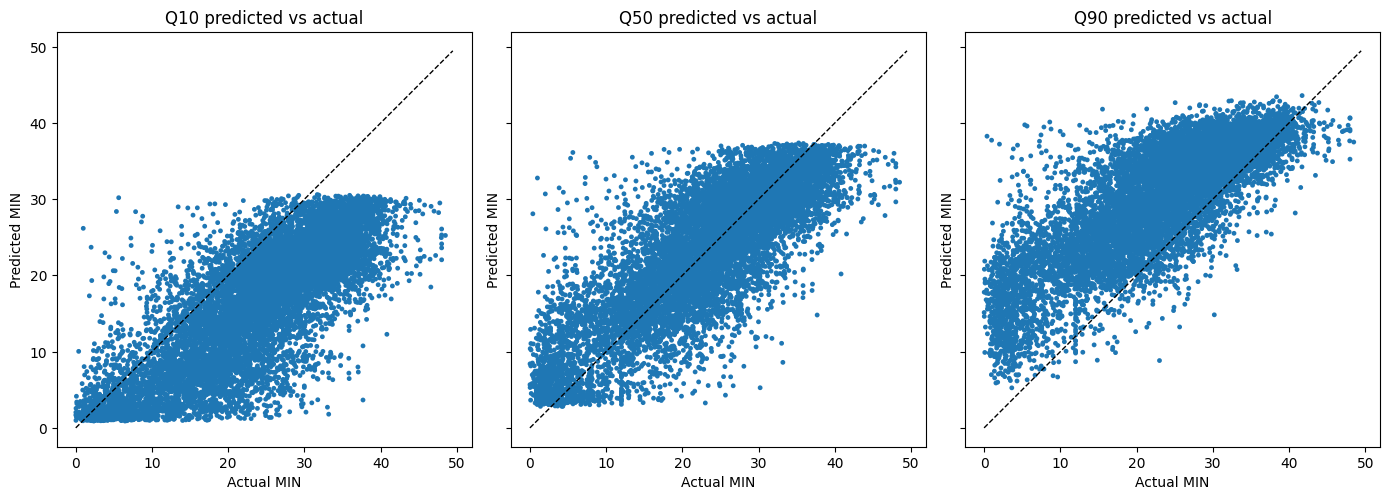

Q10 coverage: 0.10536836093660765
Q50 coverage: 0.5248429468874929
Q90 coverage: 0.9032933561774225


In [26]:
import matplotlib.pyplot as plt

y_true = y_val_f
preds = {
    "Q10": quantile_preds["q_0.10"],
    "Q50": quantile_preds["q_0.50"],
    "Q90": quantile_preds["q_0.90"],
}

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

for name, y_pred in preds.items():
    print(name, "coverage:", (y_true <= y_pred).mean())

# assumes you trained these quantiles and stored predictions
pred_low  = quantile_preds["q_0.10"]
pred_mid  = quantile_preds["q_0.50"]
pred_high = quantile_preds["q_0.90"]


── q_0.10 ──


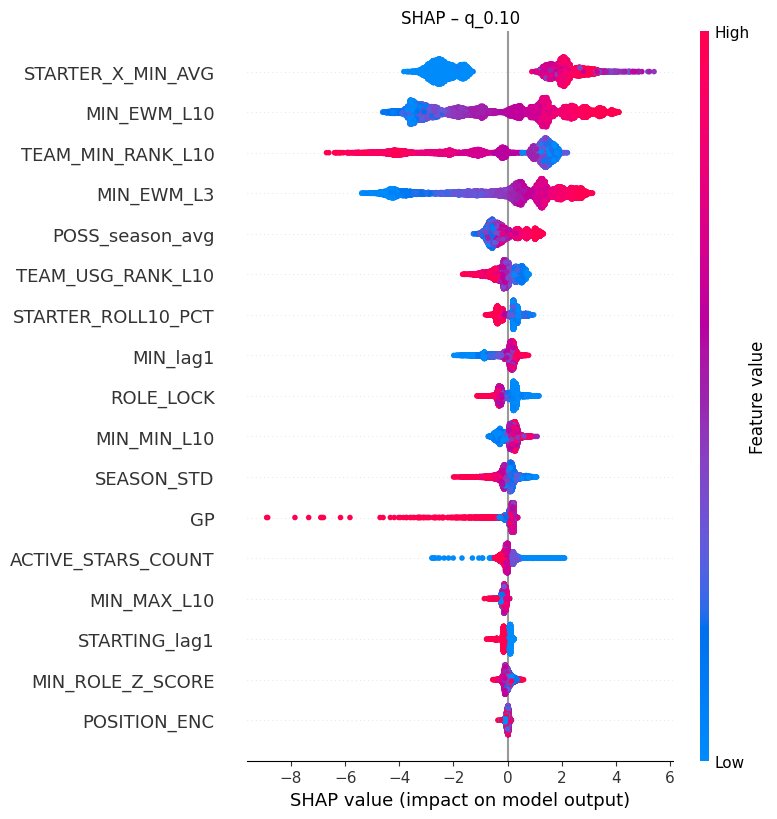


── q_0.50 ──


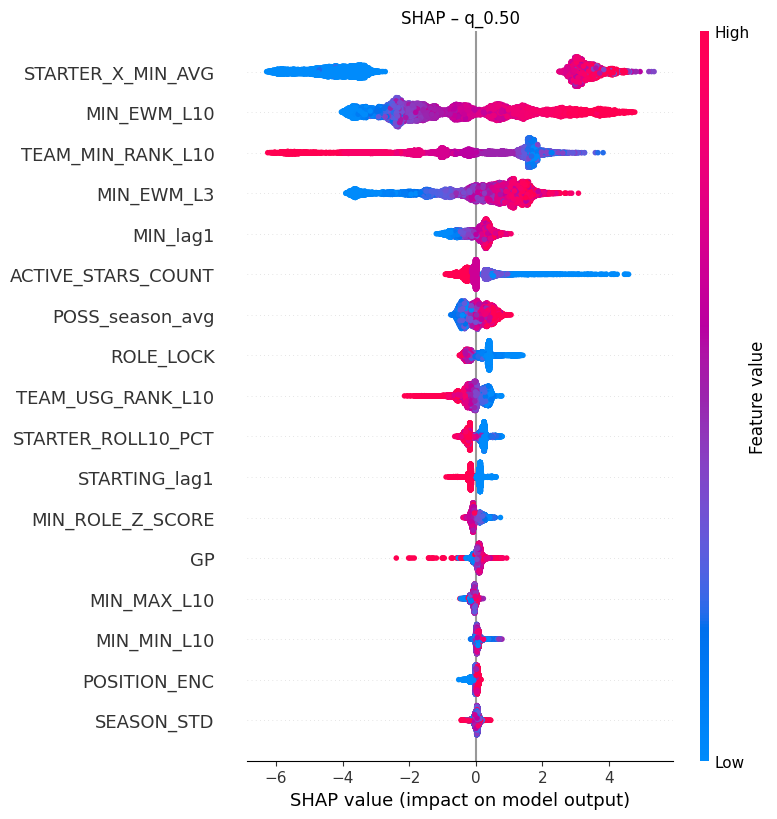


── q_0.90 ──


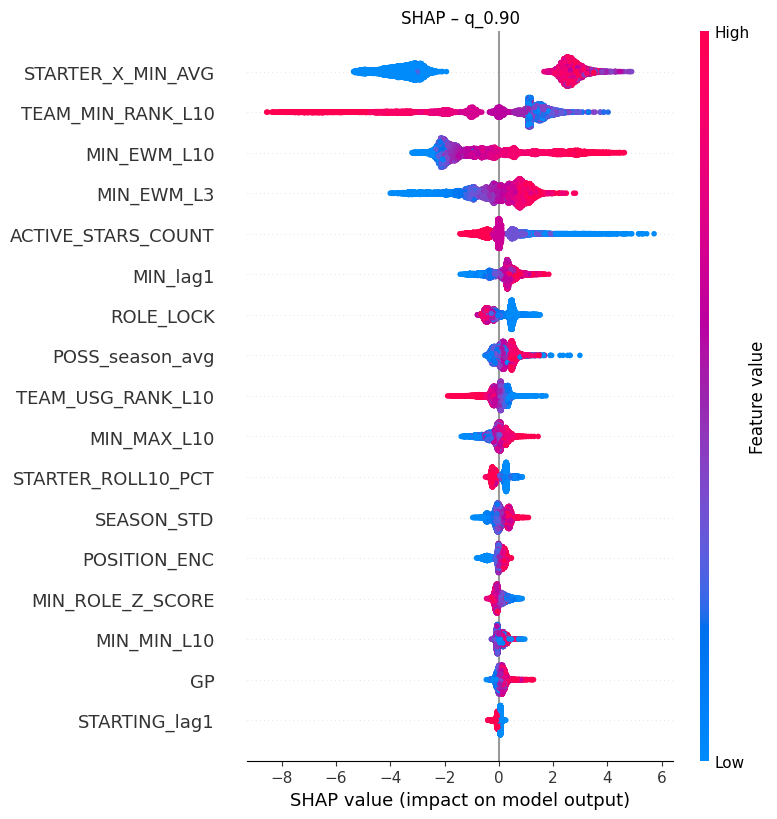

In [27]:
import shap

for q_key, model in quantile_models.items():
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_val_f)
    
    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

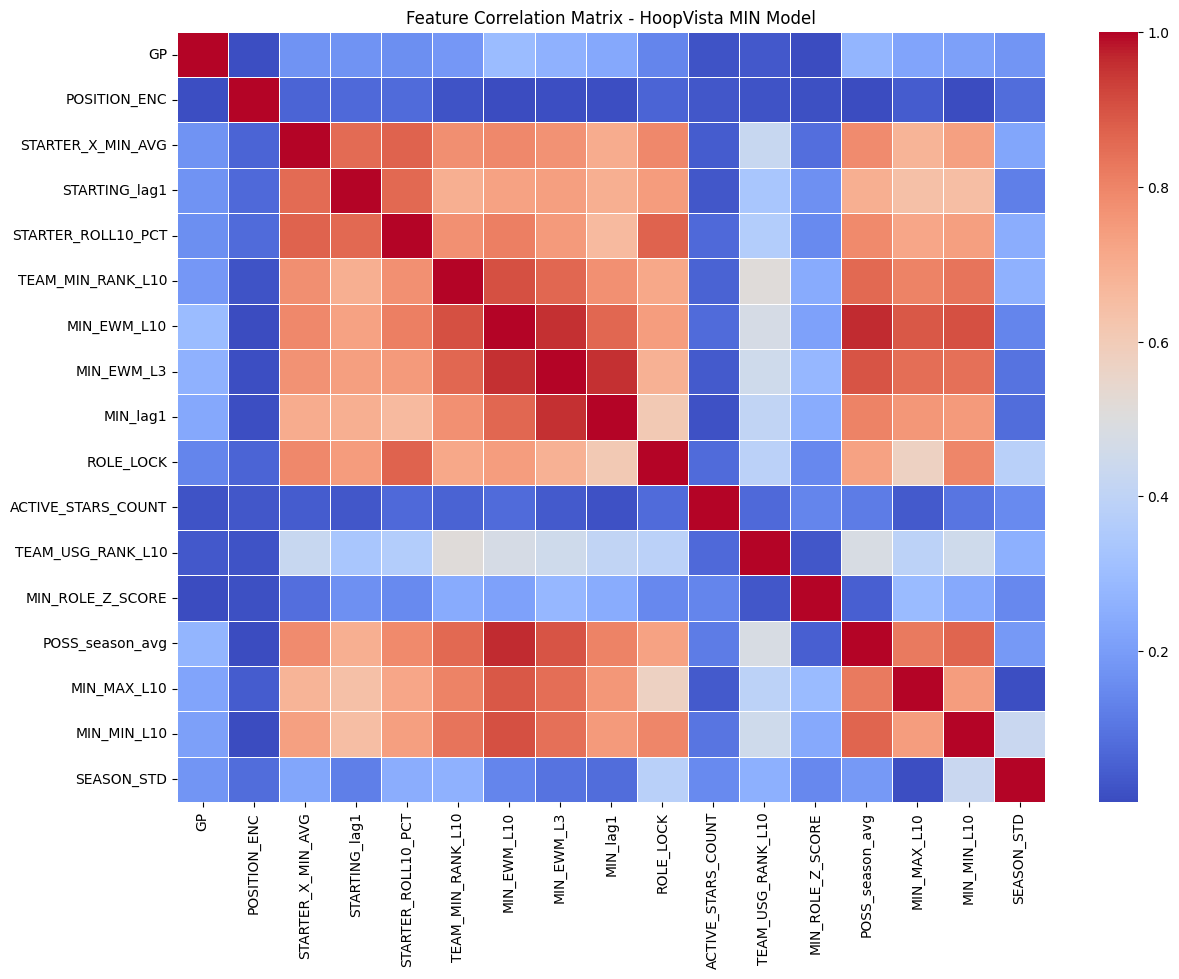

--- High Correlation Report (Threshold > 0.95) ---
POSS_season_avg <-> MIN_EWM_L10: 0.9622
MIN_EWM_L3 <-> MIN_EWM_L10: 0.9564
MIN_lag1 <-> MIN_EWM_L3: 0.9544


['MIN_EWM_L3', 'MIN_lag1', 'POSS_season_avg']

In [28]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [29]:
import joblib
from pathlib import Path


bundle = {
    "quantile_models": quantile_models,
    "feature_names": MIN_FEATURES,  # or list(X_train_min.columns)
}
joblib.dump(bundle, "min_quantile_xgb.joblib")

['min_quantile_xgb.joblib']

## Model Analysis

In [12]:
today = datetime.today().strftime('%Y%m%d')  
current_date = datetime.now().strftime('%Y-%m-%d')
target_date = pd.Timestamp("2026-03-26")
hist = df[df["GAME_DATE"] < target_date].copy()

lines_dfs = pd.read_csv('data/raw/player_lines/NBA_DFS_20260408_145444.csv')
lines_dfs = lines_dfs[(lines_dfs['BOOKMAKER'] == 'Underdog') & (lines_dfs['CATEGORY'] == 'player_points')]
names = lines_dfs['NAME'].unique()
names

array(['James Harden', 'Donovan Mitchell', 'C.J. McCollum', 'Max Strus',
       'Nickeil Alexander-Walker', 'Cade Cunningham', 'Ausar Thompson',
       'A.J. Green', 'Franz Wagner', 'Julius Randle', 'Wendell Carter Jr',
       'Anthony Black', 'Tristan da Silva', 'Jrue Holiday',
       'Scoot Henderson', 'Dylan Harper', 'Kris Murray', 'Nikola Jokic',
       'Jamal Murray', 'Aaron Gordon', 'Bruce Brown', 'Cedric Coward',
       'Cooper Flagg', 'Khris Middleton', 'Dillon Brooks',
       'Dwight Powell', 'Kawhi Leonard', 'Shai Gilgeous-Alexander',
       'Jalen Williams', 'Chet Holmgren', 'Brook Lopez', 'Derrick Jones',
       'Isaiah Hartenstein', 'Ajay Mitchell', 'Jordan Miller'],
      dtype=object)

In [13]:
records = []

for name in names:
    try:
        if name in nameDict:
            name = nameDict[name]

        features = min_pipeline(hist, name, current_date)
        min_arr = np.asarray(features, dtype=float).reshape(1, -1)

        # Use MODELS (XGBRegressor), not quantile_preds (numpy arrays)
        q50 = float(quantile_models["q_0.50"].predict(min_arr)[0])
        q10 = float(quantile_models["q_0.10"].predict(min_arr)[0])
        q90 = float(quantile_models["q_0.90"].predict(min_arr)[0])

        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": q10,
            "PRED_MIN_Q50": q50,
            "PRED_MIN_Q90": q90,
            "PRED_MIN_RANGE_10_90": q90 - q10,
        })

    except Exception as e:
        records.append({
            "PLAYER_NAME": name,
            "PRED_MIN_Q10": np.nan,
            "PRED_MIN_Q50": np.nan,
            "PRED_MIN_Q90": np.nan,
            "PRED_MIN_RANGE_10_90": np.nan,
        })
        print(f"[SKIP] {name}: {e}")

preds_df = pd.DataFrame(records)
preds_df.head()

[SKIP] James Harden: 'list' object has no attribute 'apppend'
[SKIP] Donovan Mitchell: 'list' object has no attribute 'apppend'
[SKIP] CJ McCollum: 'list' object has no attribute 'apppend'
[SKIP] Max Strus: 'list' object has no attribute 'apppend'
[SKIP] Nickeil Alexander-Walker: 'list' object has no attribute 'apppend'
[SKIP] Cade Cunningham: 'list' object has no attribute 'apppend'
[SKIP] Ausar Thompson: 'list' object has no attribute 'apppend'
[SKIP] A.J. Green: single positional indexer is out-of-bounds
[SKIP] Franz Wagner: 'list' object has no attribute 'apppend'
[SKIP] Julius Randle: 'list' object has no attribute 'apppend'
[SKIP] Wendell Carter Jr: single positional indexer is out-of-bounds
[SKIP] Anthony Black: 'list' object has no attribute 'apppend'
[SKIP] Tristan da Silva: 'list' object has no attribute 'apppend'
[SKIP] Jrue Holiday: 'list' object has no attribute 'apppend'
[SKIP] Scoot Henderson: 'list' object has no attribute 'apppend'
[SKIP] Dylan Harper: 'list' object ha

,PLAYER_NAME,PRED_MIN_Q10,PRED_MIN_Q50,PRED_MIN_Q90,PRED_MIN_RANGE_10_90
0,James Harden,NaN,NaN,NaN,NaN
1,Donovan Mitchell,NaN,NaN,NaN,NaN
2,CJ McCollum,NaN,NaN,NaN,NaN
3,Max Strus,NaN,NaN,NaN,NaN
4,Nickeil Alexander-Walker,NaN,NaN,NaN,NaN


In [14]:
import numpy as np

def run_player_simulation(row, n_sims=10000):
    sim_min = np.random.triangular(
        left=row["PRED_MIN_Q10"] * 0.85,
        mode=row["PRED_MIN_Q50"],
        right=row["PRED_MIN_Q90"] * 1.15,
        size=n_sims,
    )
    sim_min = np.clip(sim_min, 0, 48)
    return sim_min

all_sims = {}
for i, row in preds_df.iterrows():
    if not np.isnan(row["PRED_MIN_Q50"]):
        all_sims[row["PLAYER_NAME"]] = run_player_simulation(row)

In [15]:
import numpy as np
import pandas as pd

rows = []
for name, arr in all_sims.items():
    arr = np.asarray(arr, dtype=float)
    m = float(np.mean(arr))
    rows.append({
        "PLAYER_NAME": name,
        "sim_mean": round(m, 2),
        "sim_std": round(float(np.std(arr, ddof=0)), 2),
        "sim_p10": round(float(np.percentile(arr, 10)), 2),
        "sim_p90": round(float(np.percentile(arr, 90)), 2),
        "sim_interquartile_range": round(float(np.percentile(arr, 75) - np.percentile(arr, 25)), 2),
        "sim_span_p90_p10": round(float(np.percentile(arr, 90) - np.percentile(arr, 10)), 2),
        "coef_of_variation": round(float(np.std(arr) / m), 2) if m > 1 else np.nan,
    })

vol_df = pd.DataFrame(rows)
vol_df.sort_values("sim_interquartile_range", ascending=True, inplace=True)
vol_df.head(5)

KeyError: 'sim_interquartile_range'